Certainly! The bias-variance tradeoff is a fundamental concept in machine learning that helps us understand the sources of error in predictive models. Let's break it down:

### Bias
- **Definition**: Bias refers to the error due to overly simplistic assumptions in the learning algorithm. High bias can cause an algorithm to miss the relevant relations between features and target outputs (underfitting).
- **Example**: A linear model trying to fit a non-linear relationship.

### Variance
- **Definition**: Variance refers to the error due to excessive complexity in the learning algorithm. High variance can cause an algorithm to model the random noise in the training data (overfitting).
- **Example**: A very complex model (like a high-degree polynomial) that fits the training data perfectly but performs poorly on unseen data.

### Tradeoff
- The tradeoff is the balance between bias and variance. Ideally, we want a model that minimizes both bias and variance to achieve the lowest possible error.

### Code Demo with Visualization
We'll use Python with libraries like `numpy`, `matplotlib`, and `scikit-learn` to demonstrate the bias-variance tradeoff. We'll create a synthetic dataset and fit models of varying complexity to visualize the tradeoff.

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create synthetic data
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Function to plot the results
def plot_model(degree):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_train)

    # Fit the model
    model = LinearRegression()
    model.fit(X_poly, y_train)

    # Predict on training and test data
    y_train_pred = model.predict(X_poly)
    y_test_pred = model.predict(poly.transform(X_test))

    # Calculate errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', label='Data')
    plt.scatter(X_train, y_train, color='blue', label='Train Data', alpha=0.5)
    plt.scatter(X_test, y_test, color='red', label='Test Data', alpha=0.5)
    plt.plot(np.sort(X_train, axis=0), model.predict(poly.fit_transform(np.sort(X_train, axis=0))), color='green', label='Model Prediction')
    plt.title(f'Polynomial Degree: {degree}\nTrain Error: {train_error:.2f}, Test Error: {test_error:.2f}')
    plt.legend()
    plt.show()

# Plot models with varying complexity
for degree in [1, 3, 5, 10]:
    plot_model(degree)
```

### Explanation of the Code
1. **Synthetic Data**: We create a dataset with a sine function and add some noise.
2. **Train-Test Split**: We split the data into training and testing sets.
3. **Modeling**: We create polynomial features of varying degrees (1, 3, 5, 10) and fit a linear regression model.
4. **Error Calculation**: We calculate the mean squared error for both training and testing datasets.
5. **Visualization**: We plot the data points, the model predictions, and display the training and testing errors.

### Observations
- **Low Degree (High Bias)**: The model is too simple and does not capture the underlying pattern (underfitting).
- **Medium Degree (Balanced)**: The model captures the pattern well and generalizes to unseen data.
- **High Degree (High Variance)**: The model fits the training data perfectly but fails to generalize to the test data (overfitting).

This visualization helps illustrate the bias-variance tradeoff in practice. You can run the code in a Python environment with the necessary libraries installed to see the results.

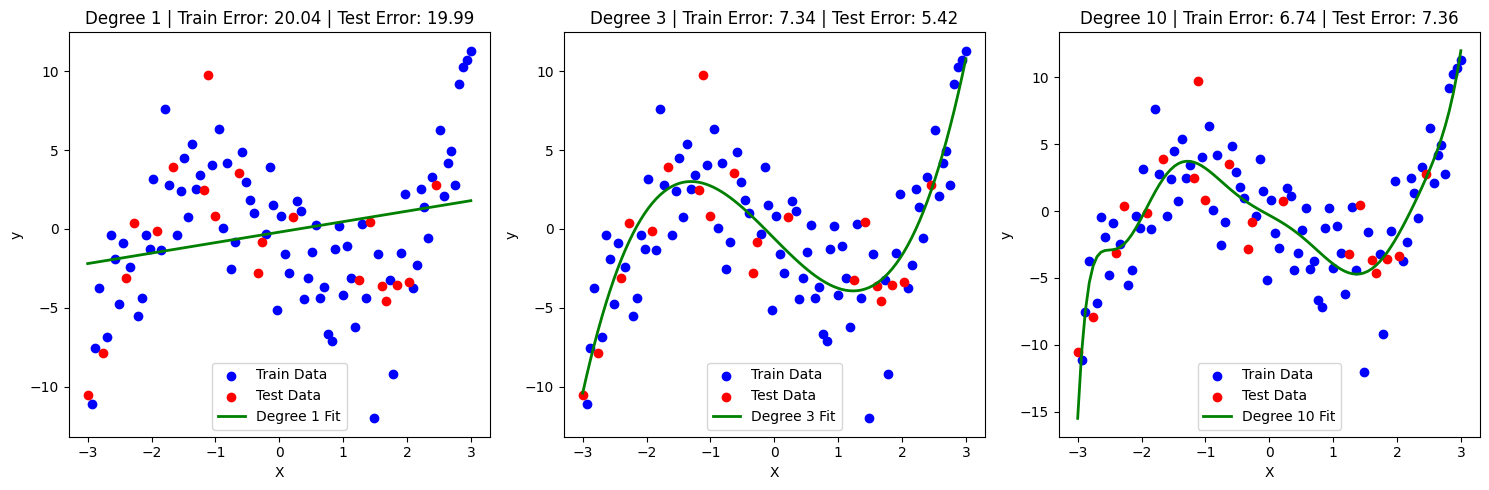

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Generate synthetic data
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)  # Features
y = X**3 - 5*X + np.random.normal(0, 3, size=X.shape)  # True function with noise

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train models with different polynomial degrees
degrees = [1, 3, 10]  # Linear, cubic, and high-degree polynomial
plt.figure(figsize=(15, 5))

for i, d in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Compute errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    # Plot results
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, y_train, color='blue', label='Train Data')
    plt.scatter(X_test, y_test, color='red', label='Test Data')
    X_range = np.linspace(-3, 3, 100).reshape(-1, 1)
    plt.plot(X_range, model.predict(X_range), color='green', lw=2, label=f'Degree {d} Fit')
    plt.title(f'Degree {d} | Train Error: {train_error:.2f} | Test Error: {test_error:.2f}')
    plt.legend()
    plt.xlabel("X")
    plt.ylabel("y")

plt.tight_layout()
plt.show()


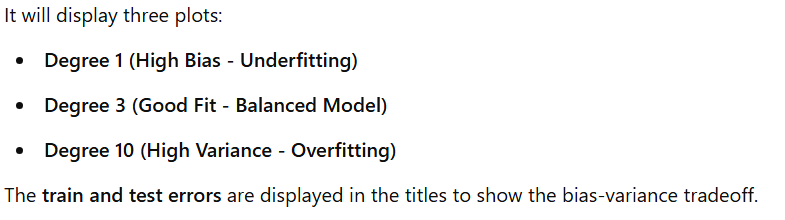

Top 10 Interview Questions on Bias-Variance Tradeoff (with Answers)
1. What is the bias-variance tradeoff in machine learning?
✅ Answer:
The bias-variance tradeoff is the balance between two types of errors:

Bias: Error due to oversimplified assumptions (leads to underfitting).

Variance: Error due to excessive sensitivity to training data (leads to overfitting).
A model should not be too simple (high bias) or too complex (high variance) to achieve the best generalization performance.

2. How does bias affect a model's performance?
✅ Answer:

High bias means the model is too simple and fails to capture the patterns in data.

It leads to underfitting, where the training and test errors are both high.

Example: Using a linear model to fit a highly non-linear dataset.

3. How does variance impact a model's generalization ability?
✅ Answer:

High variance means the model is too complex and captures noise along with patterns.

It leads to overfitting, where the training error is low, but the test error is high.

Example: Using a high-degree polynomial regression to fit a simple trend.

4. What happens when a model has high bias?
✅ Answer:

The model ignores important patterns in the data.

It performs poorly on both training and test datasets.

Example: A decision tree with only one split trying to classify complex data.

5. What happens when a model has high variance?
✅ Answer:

The model memorizes the training data instead of generalizing.

It performs well on training data but poorly on new/unseen data.

Example: A deep neural network with too many layers trained on small data.

6. Can a model have both high bias and high variance?
✅ Answer:
Yes, a model can suffer from both high bias and high variance, but it is uncommon.

This usually happens when training data is noisy and insufficient.

Example: A poorly regularized neural network trained on a small, noisy dataset.

7. How does model complexity relate to bias and variance?
✅ Answer:

Low complexity → High bias, Low variance (Underfitting)

High complexity → Low bias, High variance (Overfitting)

The goal is to find an optimal model complexity that minimizes both.

Example:

Linear regression (Low complexity, high bias)

Polynomial regression (degree 10) (High complexity, high variance)

Polynomial regression (degree 3) (Best balance)

8. What is irreducible error? Can we eliminate it?
✅ Answer:

Irreducible error is the part of error caused by noise or randomness in the data.

No model can completely eliminate it because it comes from factors beyond our control.

Example: Measurement errors, human errors, or missing information in datasets.

9. What are some real-life examples of bias and variance?
✅ Answer:

Scenario	High Bias (Underfitting)	High Variance (Overfitting)
House Price Prediction	Using only square footage to predict price	Using every tiny feature, like wall color, furniture type, etc.
Exam Score Prediction	Using just attendance to predict grades	Using every quiz and class activity without generalizing well
Image Classification	Using a simple rule-based algorithm	Using a deep neural network with excessive parameters
10. How does cross-validation help in handling bias-variance tradeoff?
✅ Answer:
Cross-validation (like k-fold CV) helps to find the right model complexity by:

Reducing variance: Prevents overfitting by testing on multiple subsets.

Detecting bias: If test performance is also poor, the model has high bias.

Choosing optimal hyperparameters: Helps in selecting the best model configuration.

